ENVIRONMENT SETUP AND DATA LOADING

In [ ]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

df = pd.read_csv('Advertising[1].csv')

df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


EXPLORATORY DATA ANALYSIS (EDA) AND CLEANING


In [ ]:
print("Missing values in each column:")
print(df.isnull().sum())

print("\nData Info:")
print(df.info())

Missing values in each column:
Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB
None


Graphs


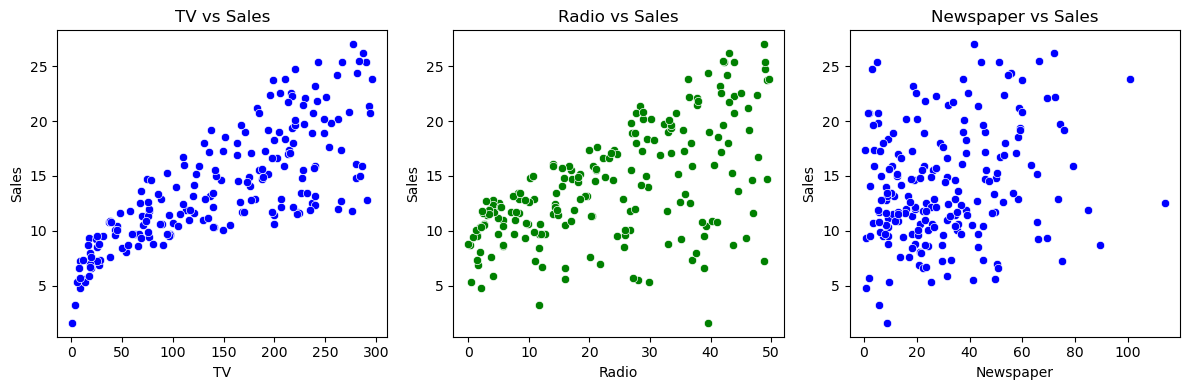

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
sns.scatterplot(data=df, x='TV', y='Sales', color='blue')
plt.title('TV vs Sales')

plt.subplot(1, 3, 2)
sns.scatterplot(data=df, x='Radio', y='Sales', color='green')
plt.title('Radio vs Sales')

plt.subplot(1, 3, 3)
sns.scatterplot(data=df, x='Newspaper', y='Sales', color='blue')
plt.title('Newspaper vs Sales')

plt.tight_layout()
plt.show()

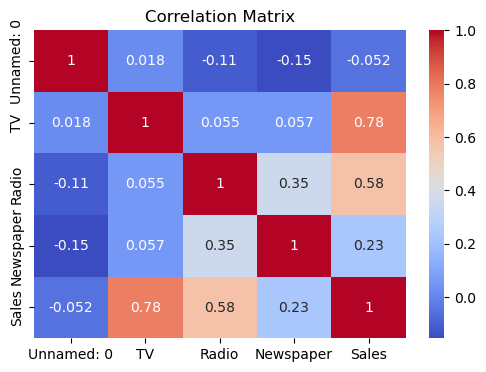

In [ ]:
plt.figure(figsize=(6, 4))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [ ]:
FUTURE SELECTION AND DATA SPLITTING

In [ ]:
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Total rows in orginal data: {X.shape[0]}")
print(f"Rows in Traininig data (80%): {X_train.shape[0]}")
print(f"Rows in Testing data (20%): {X_test.shape[0]}")

Total rows in orginal data: 200
Rows in Traininig data (80%): 160
Rows in Testing data (20%): 40


MODEL TRAINING(LINEAR REGRESSION)

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)
print("Model is successfully trained!")

y_pred = model.predict(X_test)

comparison_df = pd.DataFrame({'Actual Sales': y_test, 'Predicted sales': y_pred})
print("\nActual of first 5 rows vs predicted comparison:")
print(comparison_df.head())

Model is successfully trained!

Actual of first 5 rows vs predicted comparison:
     Actual Sales  Predicted sales
95           16.9        16.408024
15           22.4        20.889882
30           21.4        21.553843
158           7.3        10.608503
128          24.7        22.112373


MODEL EVALUATION AND BUSINESS INSIGHTS

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("--- MODEL PERFORMANCE ---")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared Score (Accuracy): {r2 * 100:.2f}%")

coefficients = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
print("\n--- BUSINESS INSIGHTS (Platform Impact) ---")
print(coefficients)

--- MODEL PERFORMANCE ---
Mean Squared Error (MSE): 3.17
R-squared Score (Accuracy): 89.94%

--- BUSINESS INSIGHTS (Platform Impact) ---
           Coefficient
TV            0.044730
Radio         0.189195
Newspaper     0.002761
